In [1]:
!pip install pandas 

In [1]:
import pandas as pd
import sqlite3
from sqlite3 import Error 
import matplotlib.pyplot as plt

In [2]:
def create_connection(path):
    connection = None
    try:
        connection = sqlite3.connect(path)
    except Error as e:
        print(f"The error {e} occured")
    return connection

connection = create_connection("../checking-logs.sqlite")

In [ ]:
df = pd.read_sql("SELECT * FROM checker WHERE uid LIKE 'user_%'", connection)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hours"] = df["timestamp"].dt.hour

df["day_of_week"] = df["timestamp"].dt.dayofweek < 5
df.loc[df["day_of_week"] == True, "working_day"] = 1
df.loc[df["day_of_week"] == False, "weekend"] = 1

weekday_n_weekend = df[["hours", "working_day", "weekend"]].copy()
all_hours = pd.DataFrame({'hours' : range(24)})
weekday_n_weekend = all_hours.merge(weekday_n_weekend, how='left', on="hours").fillna(0)
agg_func = {"working_day": "sum", "weekend": "sum"}
weekday_n_weekend  = weekday_n_weekend.groupby("hours").agg(agg_func)

working_day = weekday_n_weekend ["working_day"].tolist()
weekend = weekday_n_weekend["weekend"].tolist()



In [6]:
weekday_n_weekend

,hours,working_day,weekend
0,0,0.0,1.0
1,0,0.0,1.0
2,0,1.0,0.0
3,0,1.0,0.0
4,0,0.0,1.0
...,...,...,...
3204,23,1.0,0.0
3205,23,1.0,0.0
3206,23,1.0,0.0
3207,23,1.0,0.0


agg_func = {"working_day": "sum", "weekend": "sum"}
weekday_n_weekend  = weekday_n_weekend.groupby("hours").agg(agg_func)

working_day = weekday_n_weekend ["working_day"].tolist()
weekend = weekday_n_weekend["weekend"].tolist()

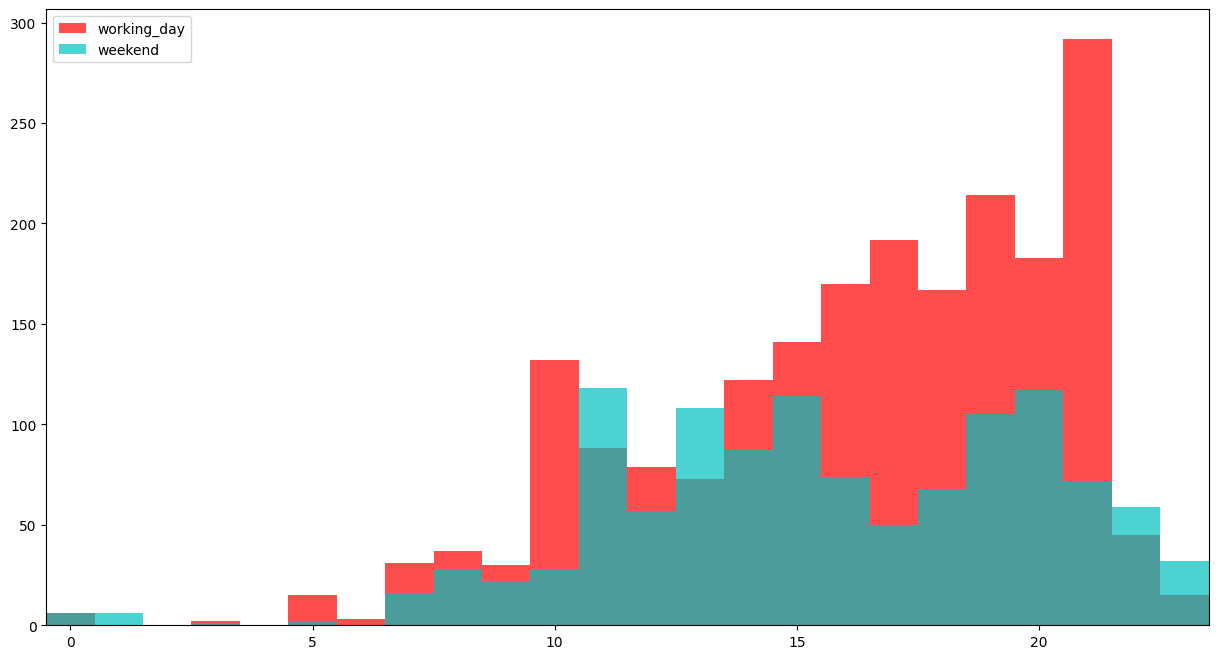

In [5]:
hours = [i for i in range(0,24)]
plt.figure(figsize=(15,8))
plt.margins(x=0)
plt.bar(hours, working_day, alpha=0.7, color="r", width=1, label="working_day")
plt.bar(hours, weekend, alpha=0.7, color="c", width=1, label="weekend")
plt.legend()
plt.show()

#### Are there hours when the total number of commits was higher on weekends than on working days? 
#### Answer: 11 13 22 23

In [6]:
connection.close()